# t-SNE практика

In [1]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

In [3]:
# Загружаем датасет
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t5_sleep.csv")

In [4]:
# Фиксируем список признаков для работы
feature_cols = [
    "age",
    "marital-status",
    "gender",
    "bmi",
    "snoring-rate",
    "respiration-rate",
    "body-temperature",
    "limb-movement",
    "blood-oxygen",
    "eye-movement",
    "sleeping-hours",
    "heart-rate",
]

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Создаём копию, чтобы не менять исходный df
X = df[feature_cols].copy()

# Проверяем размер матрицы признаков: число объектов и признаков
print("X shape:", X.shape)

# Приводим все данные к числовому формату
# Если в файле все признаки уже содержат данные типа 0/1 и float, этот шаг ничего не испортит
# errors="coerce" превращает нечисловые значения в NaN
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Заполняем пропуски медианой по каждому столбцу
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Масштабируем признаки: после StandardScaler в каждом столбце будет среднее ~0 и std ~1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Проверяем размер итоговой матрицы, которую будем передавать t-SNE
print("X_scaled shape:", X_scaled.shape)

X shape: (5000, 12)
X_scaled shape: (5000, 12)


In [7]:
from sklearn.manifold import TSNE

# 1. Создаём модель t-SNE и фиксируем ключевые параметры проекции
tsne = TSNE(
    n_components=2, # выбираем 2D-координаты
    perplexity=30, # масштаб локального окружения
    init="pca", # стартовая инициализация через PCA
    random_state=42, # фиксируем случайность для воспроизводимости
    learning_rate="auto"
)
# 2. Запускаем оптимизацию и получаем матрицу координат (n_samples, 2)
X_tsne = tsne.fit_transform(X_scaled)

# 3. Упаковываем координаты в таблицу для дальнейшей визуализации
tsne_df = pd.DataFrame(X_tsne, columns=["tsne_1", "tsne_2"])
tsne_df.head()

,tsne_1,tsne_2
0,-24.266769,-26.672655
1,-44.819202,-14.135983
2,-22.527742,36.799400
3,-0.874811,-5.188915
4,-24.825413,-14.637255


Text(0.5, 0, 'tsne_1')

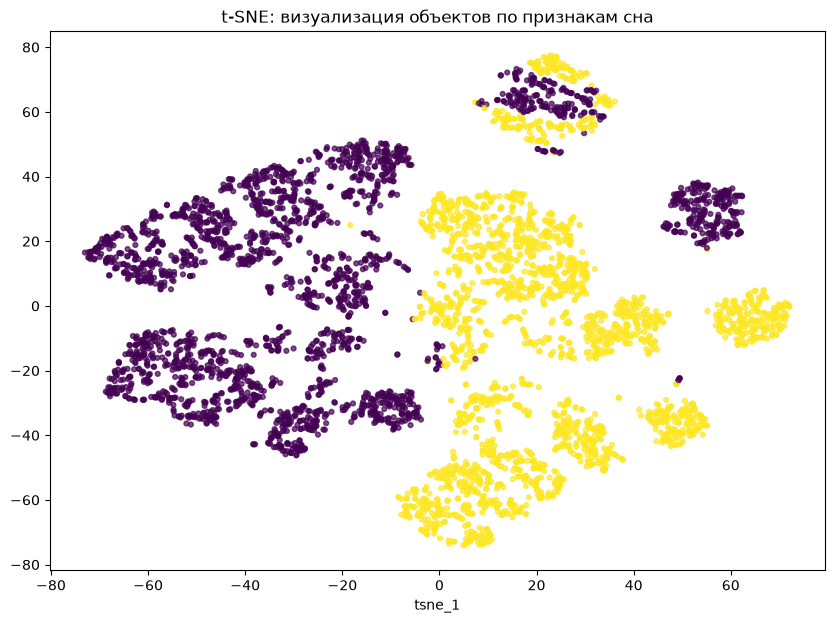

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    c=df["marital-status"],
    s=12,
    alpha=0.7,
)

plt.title("t-SNE: визуализация объектов по признакам сна")
plt.xlabel("tsne_1")

Text(0.5, 0, 'tsne_1')

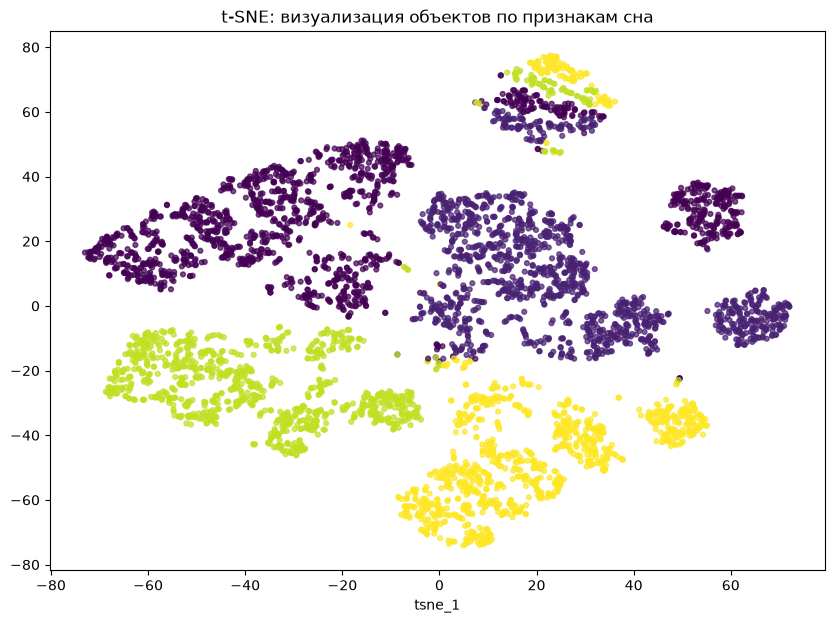

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_df["tsne_1"],
    tsne_df["tsne_2"],
    c=(df["gender"].astype(str) + df["marital-status"].astype(str)).astype(int),
    s=12,
    alpha=0.7
)

plt.title("t-SNE: визуализация объектов по признакам сна")
plt.xlabel("tsne_1")